In [37]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
import pandas as pd


FILE_URL = 'enriched_data.json'


## Creating the graph

In [24]:
with open(FILE_URL, "r") as f:
    data = f.read()
data = json.loads(data)

G = nx.Graph()

# STEP 1: Add all nodes first
for key in list(data.keys())[:14000]:
    G.add_node(
        key,
        language=data[key].get("language"),
        stars=data[key].get("stargazers_count"),
        forks=data[key].get("forks_count"),
        authors=set(data[key].get("authors", [])),  # Use set for faster lookup
        num_collab=data[key].get("number_of_collaborators", 0),
    )

# STEP 2: Add edges (only once, after all nodes exist)
repos = list(G.nodes())
for i in range(len(repos)):
    for j in range(i + 1, len(repos)):
        r1, r2 = repos[i], repos[j]
        common = G.nodes[r1]["authors"] & G.nodes[r2]["authors"]  # Set intersection
        if common:
            G.add_edge(r1, r2, weight=len(common), shared=list(common))


# Find isolates
isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)}")


G_connected = G.copy()
G_connected.remove_nodes_from(isolates)

with open('github_network_s1.pickle', 'wb') as f:
    pickle.dump(G_connected, f)


Isolated nodes: 136


## Plotting degree distribution

Nodes: 13825, Edges: 1919652
Max degree: 2594, Mean degree: 275.00
Top 10 nodes by degree:
  gregkh/usbutils: 2594
  brauner/ubuntu-focal: 2052
  tzanussi/linux-yocto-micro-3.19: 2034
  jason77-wang/eoan-rpi4: 2003
  brauner/ubuntu-disco: 1988
  jthornber/linux-2.6: 1972
  digetx/picasso-kernel: 1938
  shemminger/linux-stable: 1937
  punitagrawal/focal: 1916
  Gateworks/linux-imx6: 1913


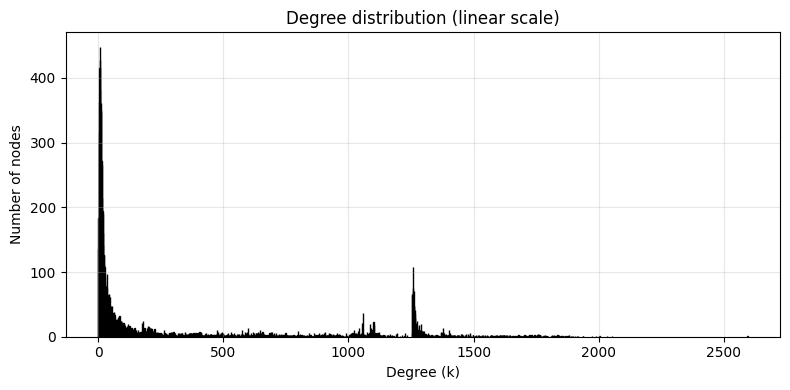

In [25]:
degrees = [d for _, d in G.degree()]
if len(degrees) == 0:
    raise RuntimeError("Graph `G` has no nodes/edges.")

deg_count = Counter(degrees)
deg_items = sorted(deg_count.items())    # list of (degree, count)
ks, counts = zip(*deg_items)
ks = np.array(ks)
counts = np.array(counts)

# Basic stats
print(f"Nodes: {G_connected.number_of_nodes()}, Edges: {G_connected.number_of_edges()}")
print(f"Max degree: {ks.max()}, Mean degree: {np.mean(degrees):.2f}")
print("Top 10 nodes by degree:")
top10 = sorted(G_connected.degree(), key=lambda x: x[1], reverse=True)[:10]
for node, deg in top10:
    print(f"  {node}: {deg}")

# 1) Linear bar histogram of degree counts
plt.figure(figsize=(8,4))
plt.bar(ks, counts, width=0.8, color='C0', edgecolor='k')
plt.xlabel('Degree (k)')
plt.ylabel('Number of nodes')
plt.title('Degree distribution (linear scale)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
n = G_connected.number_of_nodes()
avg_degree = np.mean([d for n, d in G_connected.degree()])

# In BA model: average degree ≈ 2m (for large n)
m = int(avg_degree / 2)

print(f"Your network: {n} nodes, avg degree: {avg_degree:.2f}")
print(f"BA parameters: n={n}, m={m}")

# Generate comparable BA model
G_ba = nx.barabasi_albert_graph(n, m)

Your network: 13825 nodes, avg degree: 277.71
BA parameters: n=13825, m=138


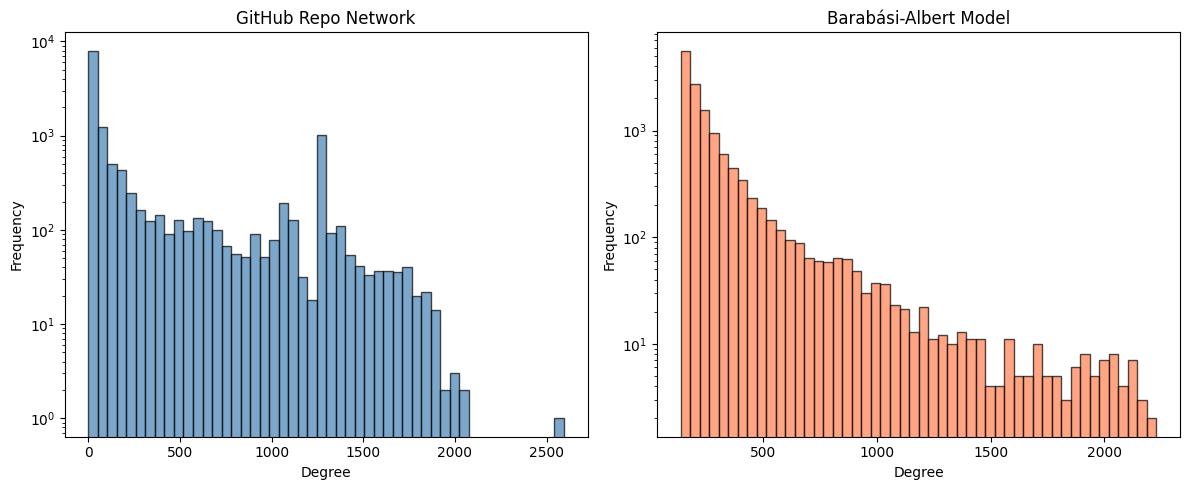

In [28]:
# Get degree sequences
degrees_real = [d for n, d in G_connected.degree()]
degrees_ba = [d for n, d in G_ba.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Your network
ax1.hist(degrees_real, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Frequency')
ax1.set_title('GitHub Repo Network')
ax1.set_yscale('log')

# BA model
ax2.hist(degrees_ba, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Degree')
ax2.set_ylabel('Frequency')
ax2.set_title('Barabási-Albert Model')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('degree_comparison_ba.png')
plt.show()

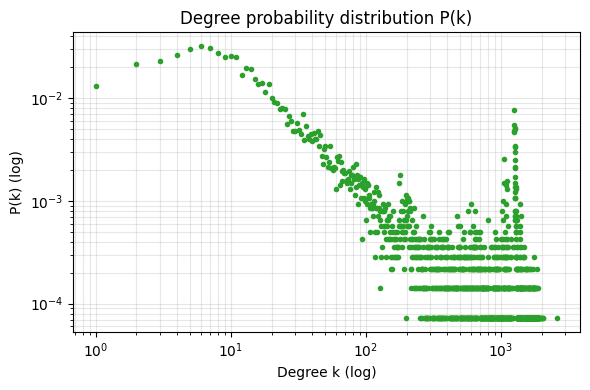

In [26]:
nonzero = ks > 0
k_nz = ks[nonzero]
c_nz = counts[nonzero]

plt.figure(figsize=(6,4))
p_k = counts / counts.sum()
plt.loglog(ks[nonzero], p_k[nonzero], marker='.', linestyle='none', color='C2')
plt.xlabel('Degree k (log)')
plt.ylabel('P(k) (log)')
plt.title('Degree probability distribution P(k)')
plt.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Stats:

In [31]:
degrees = [d for n, d in G_connected.degree()]
print(f"\n=== Connected Component ===")
print(f"Nodes: {G_connected.number_of_nodes()}")
print(f"Edges: {G_connected.number_of_edges()}")
print(f"Avg degree: {np.mean(degrees):.2f}")
print(f"Max degree: {max(degrees)}")
print(f"Min degree: {min(degrees)}")
print(f"Std degree: {np.std(degrees):.2f}")

# Clustering coefficient
#print(f"Avg clustering: {nx.average_clustering(G_connected):.4f}")


=== Connected Component ===
Nodes: 13825
Edges: 1919652
Avg degree: 277.71
Max degree: 2594
Min degree: 1
Std degree: 461.84


In [43]:
# Calculate centrality measures
degree_cent = nx.degree_centrality(G_connected)
print(f"Calculated degree centrality for {len(degree_cent)} nodes.")
#betweenness_cent = nx.betweenness_centrality(G_connected)
#print(f"Calculated betweenness centrality for {len(betweenness_cent)} nodes.")
eigenvector_cent = nx.eigenvector_centrality(G_connected, max_iter=1000)
#print(f"Calculated eigenvector centrality for {len(eigenvector_cent)} nodes.")
#closeness_cent = nx.closeness_centrality(G_connected)
#print(f"Calculated closeness centrality for {len(closeness_cent)} nodes.")

# Store in a DataFrame for easy analysis
centrality_df = pd.DataFrame({
    'repo': list(G_connected.nodes()),
    'degree': [degree_cent[n] for n in G_connected.nodes()],
    #'betweenness': [betweenness_cent[n] for n in G_connected.nodes()],
    'eigenvector': [eigenvector_cent[n] for n in G_connected.nodes()],
    #'closeness': [closeness_cent[n] for n in G_connected.nodes()],
    'stars': [G_connected.nodes[n].get('stars', 0) for n in G_connected.nodes()],
    'forks': [G_connected.nodes[n].get('forks', 0) for n in G_connected.nodes()],
    'language': [G_connected.nodes[n].get('language', 'Unknown') for n in G_connected.nodes()],
})

Calculated degree centrality for 13825 nodes.


In [39]:
def top_by_centrality(df, measure, n=10):
    print(f"\n=== Top {n} by {measure.upper()} ===")
    top = df.nlargest(n, measure)[['repo', measure, 'stars', 'language']]
    for i, row in top.iterrows():
        print(f"{row['repo']:40} | {measure}: {row[measure]:.4f} | ⭐ {row['stars']:,}")

top_by_centrality(centrality_df, 'degree')
#top_by_centrality(centrality_df, 'betweenness')
top_by_centrality(centrality_df, 'eigenvector')
#top_by_centrality(centrality_df, 'closeness')


=== Top 10 by DEGREE ===
gregkh/usbutils                          | degree: 0.1876 | ⭐ 419.0
brauner/ubuntu-focal                     | degree: 0.1484 | ⭐ 0.0
tzanussi/linux-yocto-micro-3.19          | degree: 0.1471 | ⭐ 2.0
jason77-wang/eoan-rpi4                   | degree: 0.1449 | ⭐ 1.0
brauner/ubuntu-disco                     | degree: 0.1438 | ⭐ 1.0
jthornber/linux-2.6                      | degree: 0.1427 | ⭐ 9.0
digetx/picasso-kernel                    | degree: 0.1402 | ⭐ 2.0
shemminger/linux-stable                  | degree: 0.1401 | ⭐ 1.0
punitagrawal/focal                       | degree: 0.1386 | ⭐ 2.0
Gateworks/linux-imx6                     | degree: 0.1384 | ⭐ 13.0

=== Top 10 by EIGENVECTOR ===
gregkh/usbutils                          | eigenvector: 0.0286 | ⭐ 419.0
Mic92/nix-update                         | eigenvector: 0.0285 | ⭐ 679.0
ahmetb/kubectl-tree                      | eigenvector: 0.0285 | ⭐ 3,261.0
ahmetb/kubectl-foreach                   | eigenvector: 0.0

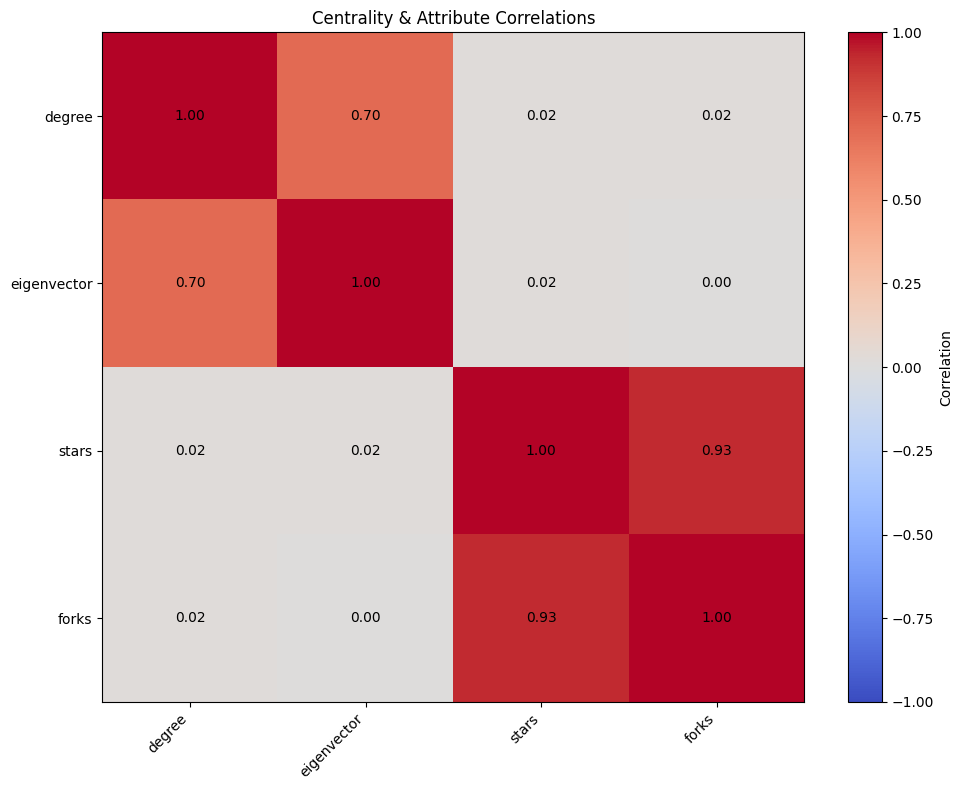

In [44]:
# Correlation matrix
correlation_cols = ['degree', 'eigenvector', 'stars', 'forks']
corr_matrix = centrality_df[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45, ha='right')
plt.yticks(range(len(correlation_cols)), correlation_cols)

# Add correlation values
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', fontsize=10)

plt.title('Centrality & Attribute Correlations')
plt.tight_layout()
plt.savefig('centrality_correlation.png')
plt.show()

Degree Assortativity: 0.2832


C:\Users\sssch\AppData\Local\Temp\ipykernel_37556\2175249339.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\sssch\AppData\Local\Temp\ipykernel_37556\2175249339.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('degree_assortativity.png')
C:\Users\sssch\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


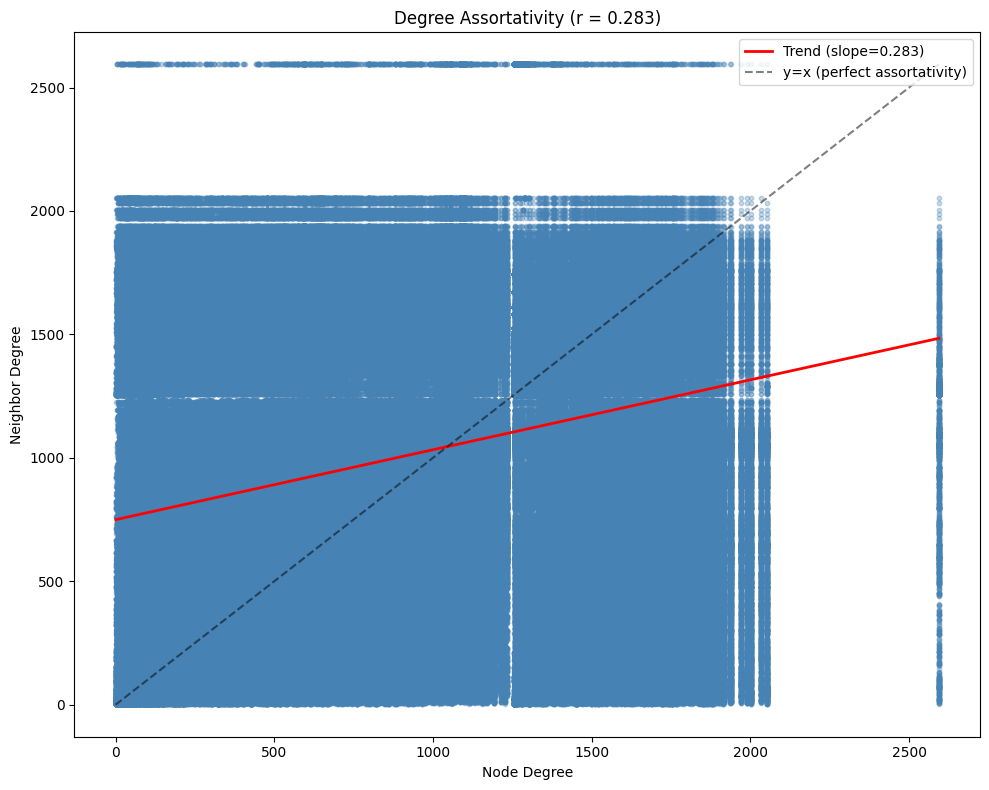

In [45]:
# Calculate degree assortativity
degree_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree Assortativity: {degree_assortativity:.4f}")
# The higher the value, the more likely nodes connect to others with similar degree.

# Get degree of each node and its neighbors
degree_dict = dict(G_connected.degree())

source_degrees = []
target_degrees = []

for u, v in G_connected.edges():
    source_degrees.append(degree_dict[u])
    target_degrees.append(degree_dict[v])
    # Add reverse since undirected
    source_degrees.append(degree_dict[v])
    target_degrees.append(degree_dict[u])

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(source_degrees, target_degrees, alpha=0.3, s=10, color='steelblue')

# Add trend line
z = np.polyfit(source_degrees, target_degrees, 1)
p = np.poly1d(z)
x_line = np.linspace(min(source_degrees), max(source_degrees), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend (slope={z[0]:.3f})')

# Add diagonal reference
max_val = max(max(source_degrees), max(target_degrees))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x (perfect assortativity)')

plt.xlabel('Node Degree')
plt.ylabel('Neighbor Degree')
plt.title(f'Degree Assortativity (r = {degree_assortativity:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('degree_assortativity.png')
plt.show()